# Lecture Week 3: Data visualization (Pandas)

In [2]:
import pandas as pd
import scipy

import warnings
warnings.filterwarnings('ignore') # hide all warnings that would normally appear in the output.

**Why use it?**

Sometimes warnings are **not errors** and do not affect the results, for example:


- **Deprecation** warnings from libraries
- **Future changes** in library behaviour
- **Display-related** warnings in notebooks

Suppressing them can make notebook output **cleaner**.

## Get the data

preprocessed last week and saved as pickle.

In [6]:
mortality_data = pd.read_pickle('mortality_prepped.pkl')
print(mortality_data.shape)
mortality_data.head(3) # prefered for algorithms

(476, 4)


,Year,AgeGroup,DeathRate,MeanCentered
0,1900,01-04 Years,1983.8,1790.87584
1,1901,01-04 Years,1695.0,1502.07584
2,1902,01-04 Years,1655.7,1462.77584


In [8]:
mortality_wide = pd.read_pickle('mortality_wide.pkl')
print(mortality_wide.shape)
mortality_wide.head() # human readability

(119, 4)


AgeGroup,01-04 Years,05-09 Years,10-14 Years,15-19 Years
Year,,,,
1900,1983.8,466.1,298.3,484.8
1901,1695.0,427.6,273.6,454.4
1902,1655.7,403.3,252.5,421.5
1903,1542.1,414.7,268.2,434.1
1904,1591.5,425.0,305.2,471.4


## Long vs. wide data

In [9]:
# # Select the data for the age group "01-04 Years" using the query() method
# # and create a scatter plot of death rates against year
# mortality_data.query('AgeGroup == "01-04 Years"').plot.scatter(x='Year', y='DeathRate')
# # y is necessary; otherwise, it raises an error

<Axes: xlabel='Year'>

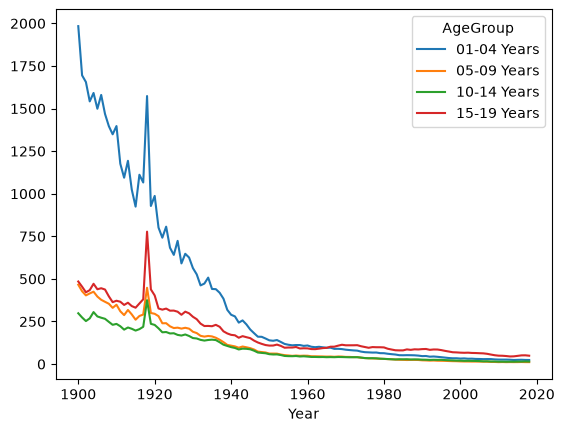

In [10]:
# create a line plot of death rates against year
mortality_wide.plot() # index forms horizontal axis   
# y="01-04 Years" y is arbitrary

## Difference in plotting wide and long dataframes

### Wide Format
In a wide table, each **variable** that you want to plot is **already in its own column**. Pandas automatically plots **all the remaining numeric columns as separate lines** (or bars, depending on the plot type). 

Advantage: You often don't need to specify the y columns because Pandas uses all numeric columns by default.

### Long (Tidy) Format
You usually need to **specify which column contains the values**. However, this will **plot all columns** together because Pandas doesn't automatically know which column to represent.


<img src="wide.jpg" width="600" />

## Plot the data

<Axes: >

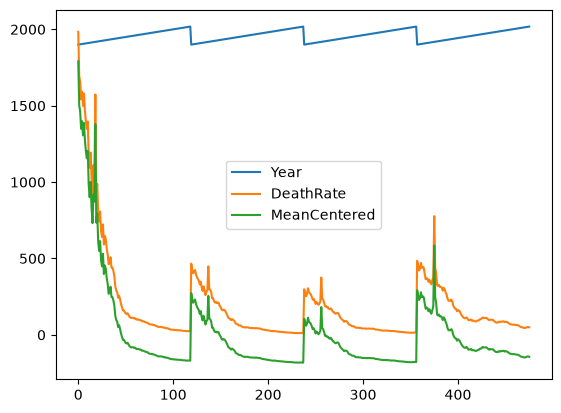

In [16]:
# Create a plot of all columns in the DataFrame 'mortality_data'
mortality_data.plot(kind ='line') #  hist, box, bar, barh,  area, kde

In [17]:
# # Create a line plot for the death rates of age groups "01-04 Years" and "15-19 Years"
# # using the 'plot.line()' method and 
# # specifying the columns to be plotted with the 'y' parameter
# mortality_wide.plot.line(y=['01-04 Years','15-19 Years'])

**df.plot(kind='line')**

- **Dynamic**; swap chart types **seamlessly** by updating a **string variable**.


**df.plot.line()**      

- **Static**; requires **rewriting** the actual method call to switch plot types.

## Line and area plots

<Axes: xlabel='Year'>

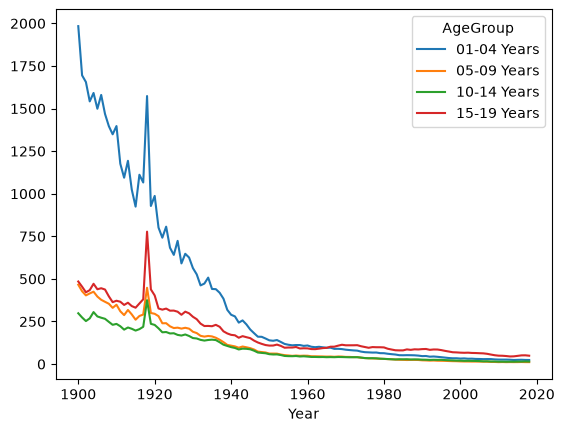

In [19]:
# Create a line plot for all columns in the DataFrame 'mortality_wide'
# using the 'plot.line()' method
mortality_wide.plot.line() # same as .plot()

## Line plot: Improvement the Appreance

<Axes: title={'center': 'Child Mortality: 1900-2018'}, xlabel='Year', ylabel='Deaths per 100,000'>

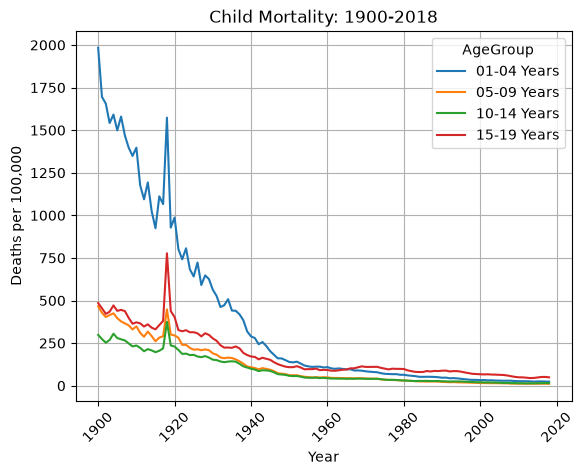

In [25]:
# Create a line plot for each column in the DataFrame 'mortality_wide'
# using the 'plot.line()' method and set the plot title, 
# y-axis label, grid, and x-axis label rotation
mortality_wide.plot.line(title='Child Mortality: 1900-2018', ylabel='Deaths per 100,000', grid=True, rot=45)

<Axes: title={'center': 'Child Mortality: 2000-2018'}, xlabel='Year', ylabel='Deaths per 100,000'>

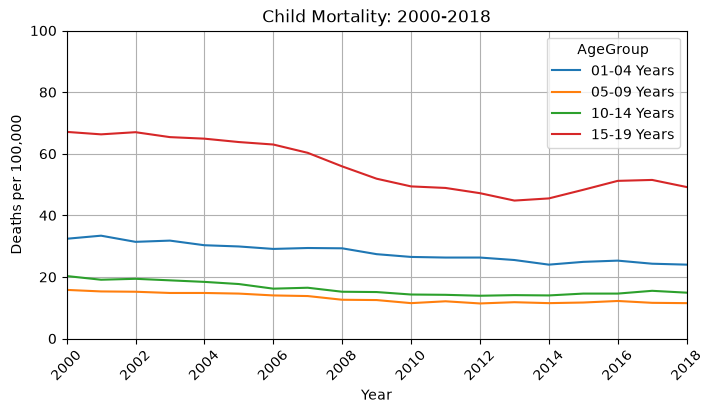

In [22]:
# Create a line plot for each column in the DataFrame 'mortality_wide' 
# using the 'plot.line()' method and set the plot title, y-axis label, figure size, grid, 
# x-axis label rotation, x-axis limits, and y-axis limits
mortality_wide.plot.line(title='Child Mortality: 2000-2018', 
                         ylabel='Deaths per 100,000', figsize=(8,4), grid=True, rot=45, 
                         xlim=(2000,2018), ylim=(0,100))

## Scatter plots

   Year     AgeGroup  DeathRate  MeanCentered
0  1900  01-04 Years     1983.8    1790.87584
1  1901  01-04 Years     1695.0    1502.07584
2  1902  01-04 Years     1655.7    1462.77584


<Axes: xlabel='Year', ylabel='DeathRate'>

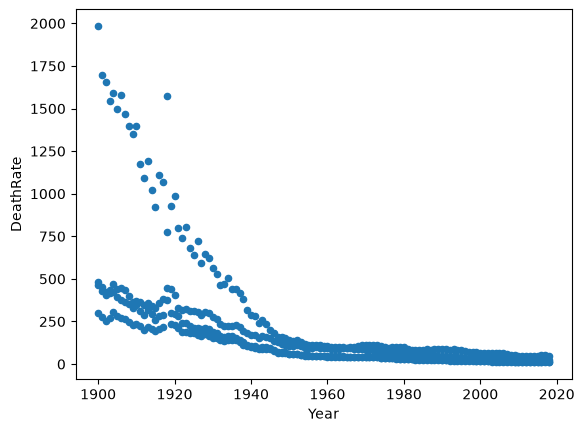

In [24]:
# Create a scatter plot of death rates against year using the 'plot.scatter()' method 
# on the DataFrame 'mortality_data', specifying the columns to be plotted with the 'x' and 'y' parameters
print(mortality_data.head(3))
mortality_data.plot.scatter(x='Year', y='DeathRate')

<Axes: xlabel='Year'>

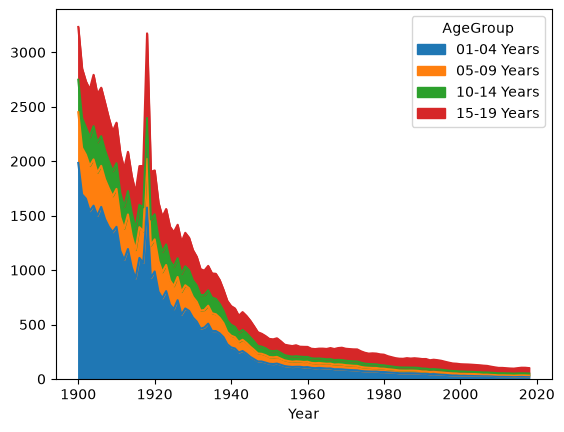

In [25]:
# Create an area plot for all columns in the DataFrame 'mortality_wide'
# using the 'plot.area()' method
mortality_wide.plot.area()

## Bar plots

AgeGroup  01-04 Years  05-09 Years  10-14 Years  15-19 Years
Year                                                        
1900           1983.8        466.1        298.3        484.8
2000             32.4         15.8         20.3         67.1


<Axes: xlabel='Year'>

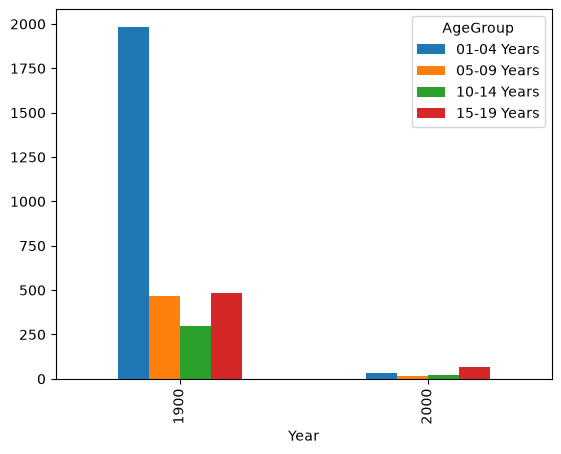

In [28]:
# Create a bar plot of the columns in the DataFrame 'mortality_wide' 
# that have years 1900 or 2000 using the 'plot.bar()' method 
# on the subset of data obtained by using the 'query()' method
print(mortality_wide.query('Year in (1900,2000)'))

mortality_wide.query('Year in (1900,2000)').plot.bar() # index -> grouped bar

<Axes: ylabel='Year'>

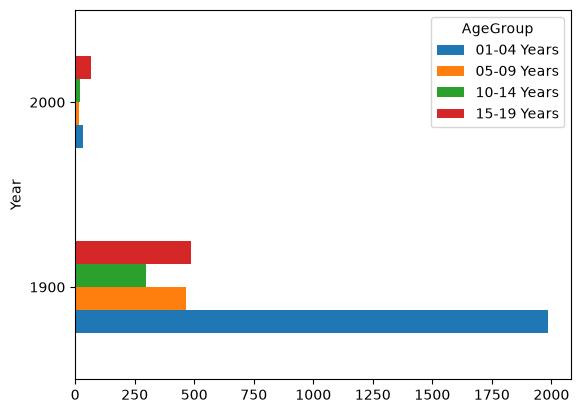

In [47]:
# Create a horizantal bar plot of the columns in the DataFrame 'mortality_wide' 
# that have years 1900 or 2000 using the 'plot.bar()' method 
# on the subset of data obtained by using the 'query()' method
mortality_wide.query('Year in (1900,2000)').plot.barh()

## Histogram and density plots

### Histogram 

A histogram is a graph that shows the **distribution of numerical data** by grouping values into **intervals**, called **bins**, and counting **how many observations** fall within each interval.

Unlike a **bar chart**, which compares **categories**, a histogram helps you understand **how numerical data are distributed**.

   Year     AgeGroup  DeathRate  MeanCentered
0  1900  01-04 Years     1983.8    1790.87584
1  1901  01-04 Years     1695.0    1502.07584
2  1902  01-04 Years     1655.7    1462.77584
3  1903  01-04 Years     1542.1    1349.17584
4  1904  01-04 Years     1591.5    1398.57584


<Axes: ylabel='Frequency'>

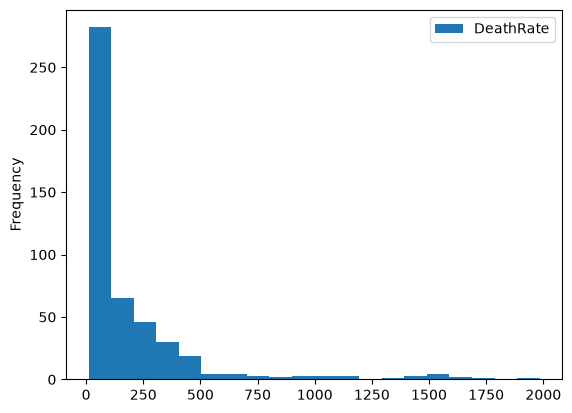

In [36]:
# Create a histogram of the 'DeathRate' column in the DataFrame 'mortality_data'
# using the 'plot.hist()' method with 8 bins
print(mortality_data.head())
mortality_data.plot.hist(y='DeathRate', bins=20)

- The **x-axis** represents the **values (or ranges/bins) of the variable**.

- The **y-axis** represents the **frequency (count)** of observations in each range.

### Kernel Density Estimate (KDE) Plot

It is also called a **density plot**, is a graph that estimates the **probability density function of a continuous numerical variable**.

Instead of grouping data into bars like a histogram, a KDE plot displays a **smooth curve** that shows where data values are concentrated.

   Year     AgeGroup  DeathRate  MeanCentered
0  1900  01-04 Years     1983.8    1790.87584
1  1901  01-04 Years     1695.0    1502.07584
2  1902  01-04 Years     1655.7    1462.77584


<Axes: ylabel='Density'>

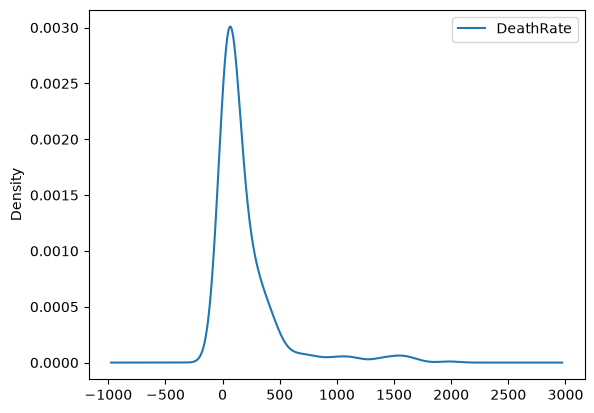

In [44]:
# Create a kernel density estimate plot of the 'DeathRate' column 
# in the DataFrame 'mortality_data' using the 'plot.density()' method
print(mortality_data.head(3))
mortality_data.plot.density(y='DeathRate') #

AgeGroup  01-04 Years  05-09 Years  10-14 Years  15-19 Years
Year                                                        
1900           1983.8        466.1        298.3        484.8
1901           1695.0        427.6        273.6        454.4
1902           1655.7        403.3        252.5        421.5


<Axes: ylabel='Density'>

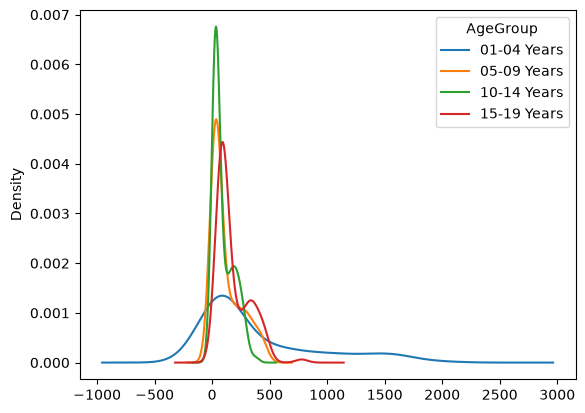

In [48]:
# Create a kernel density estimate plot for each column 
# in the DataFrame 'mortality_wide' using the 'plot.density()' method
print(mortality_wide.head(3))
mortality_wide.plot.density() #y=['15-19 Years', '05-09 Years']

## Box and pie plots

<Axes: >

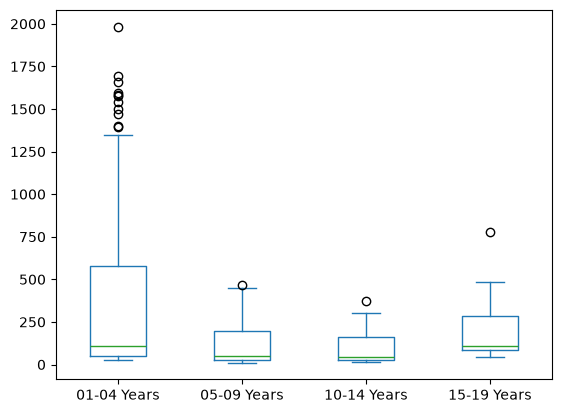

In [66]:
# Create a box plot for each column in the DataFrame 'mortality_wide'
# using the 'plot.box()' method
mortality_wide.plot.box()

<Axes: >

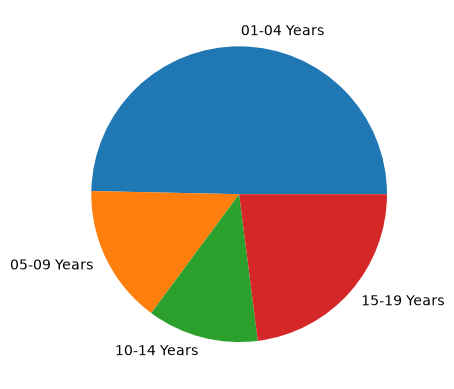

In [68]:
# Group the DataFrame 'mortality_data' by 'AgeGroup', 
# sum the 'DeathRate' column for each group,
# and create a pie chart using the 'plot.pie()' method
mortality_data.groupby('AgeGroup')['DeathRate'].sum().plot.pie()

## Subplots

array([[<Axes: title={'center': 'Child Mortality: 01-04'}, xlabel='Year', ylabel='Deaths per 100,000'>,
        <Axes: title={'center': 'Child Mortality: 05-09'}, xlabel='Year', ylabel='Deaths per 100,000'>],
       [<Axes: title={'center': 'Child Mortality: 10-14'}, xlabel='Year', ylabel='Deaths per 100,000'>,
        <Axes: title={'center': 'Child Mortality: 15-19'}, xlabel='Year', ylabel='Deaths per 100,000'>]],
      dtype=object)

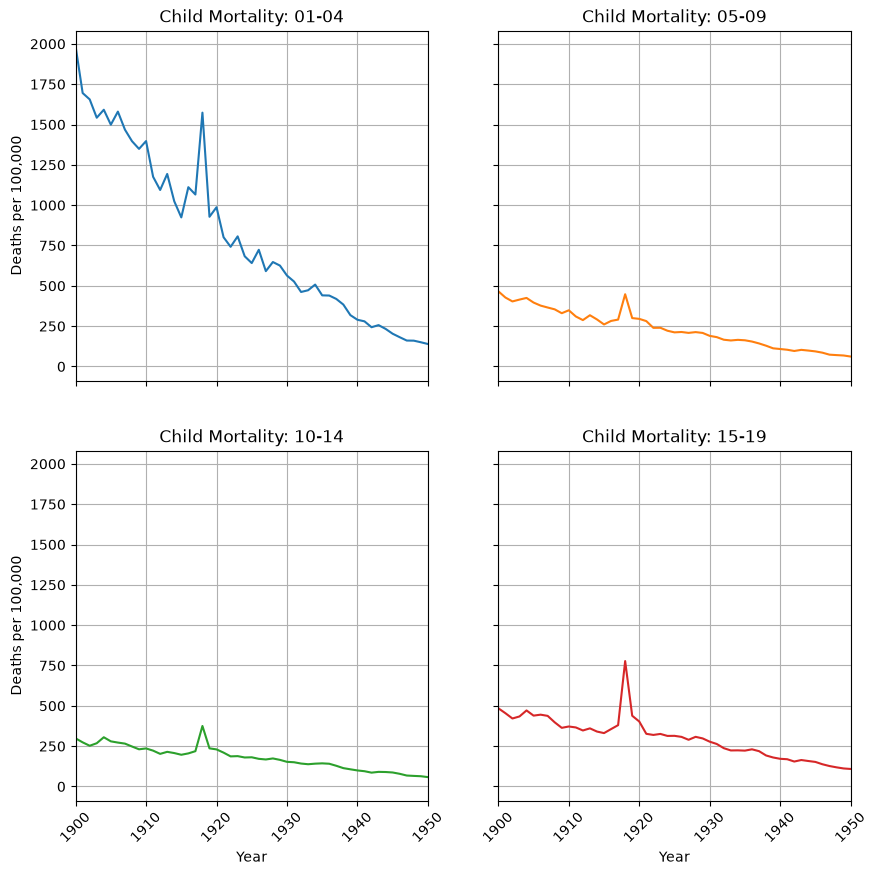

In [56]:
# Create a line plot for each column in the DataFrame 'mortality_wide'
# using the 'plot.line()' method and set the plot title, y-axis label,
# sharing y-axis between subplots, grid, x-axis label rotation, x-axis limits,
# disable legend, create subplots, set layout, and figure size.
mortality_wide.plot.line(title=['Child Mortality: 01-04', 'Child Mortality: 05-09',
                                'Child Mortality: 10-14', 'Child Mortality: 15-19'],
                         ylabel='Deaths per 100,000', sharey=True,
                         grid=True, rot=45, xlim=(1900, 1950), legend=False,
                         subplots=True, layout=(2, 2), figsize=(10, 10))

## Chaining

<Axes: ylabel='AgeGroup'>

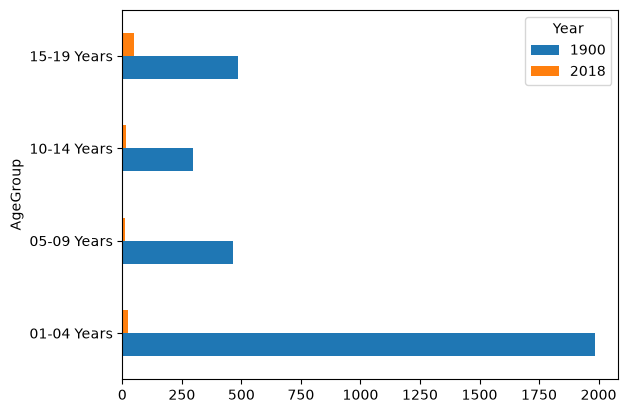

In [34]:
# filter the data to include only 1900 and 2018
# reshape the data into a pivot table
# plot a horizontal bar chart of the pivot table
mortality_data.query('Year in (1900,2018)').\
pivot(index='AgeGroup', columns='Year', values='DeathRate').plot.barh()

<Axes: xlabel='Year', ylabel='Deaths per 100,000'>

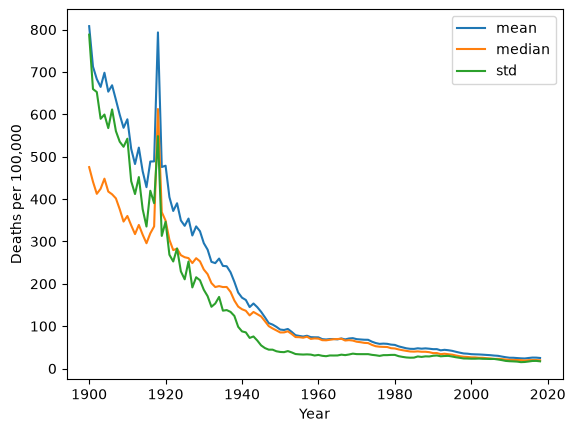

In [36]:
# group the data by year and calculate the mean, median, 
# and standard deviation of the death rate for each year
grouped_data = mortality_data.groupby('Year')['DeathRate'].agg(['mean','median','std'])

# plot the mean, median, and standard deviation of the death rate for each year
grouped_data.plot(ylabel='Deaths per 100,000')